<a href="https://colab.research.google.com/github/jessediniz17/matriz-confusao/blob/main/Matriz_de_Confusao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
pip install -q tensorflow

In [6]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import pandas as pd

In [7]:
%load_ext tensorboard

In [8]:
logdir='log'

In [9]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# CIFAR-10 images are 32x32 with 3 color channels (RGB).
# No reshape is needed here as load_data() already returns them in this format.
# If you intend to convert them to grayscale or a different size, that would require more complex preprocessing.

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Verify shapes after loading and before any potential custom reshaping
print(f"Shape of train_images: {train_images.shape}")
print(f"Shape of test_images: {test_images.shape}")

classes = [0,1,2,3,4,5,6,7,8,9]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Shape of train_images: (50000, 32, 32, 3)
Shape of test_images: (10000, 32, 32, 3)


In [10]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit (x=train_images,
           y=train_labels,
           epochs=5,
           validation_data=(test_images, test_labels),
           callbacks=[tensorboard_callback])

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.1119 - loss: 3.9831 - val_accuracy: 0.1015 - val_loss: 3.7890
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.0990 - loss: 3.8060 - val_accuracy: 0.0461 - val_loss: 3.7915
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.1029 - loss: 3.8015 - val_accuracy: 0.1070 - val_loss: 3.8090
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.1021 - loss: 3.8100 - val_accuracy: 0.1000 - val_loss: 3.8090
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.1000 - loss: 3.8090 - val_accuracy: 0.1000 - val_loss: 3.8090


In [15]:
y_true=test_labels
y_pred=model.predict(test_images)
y_pred=np.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [16]:
classes=[0,1,2,3,4,5,6,7,8,9]

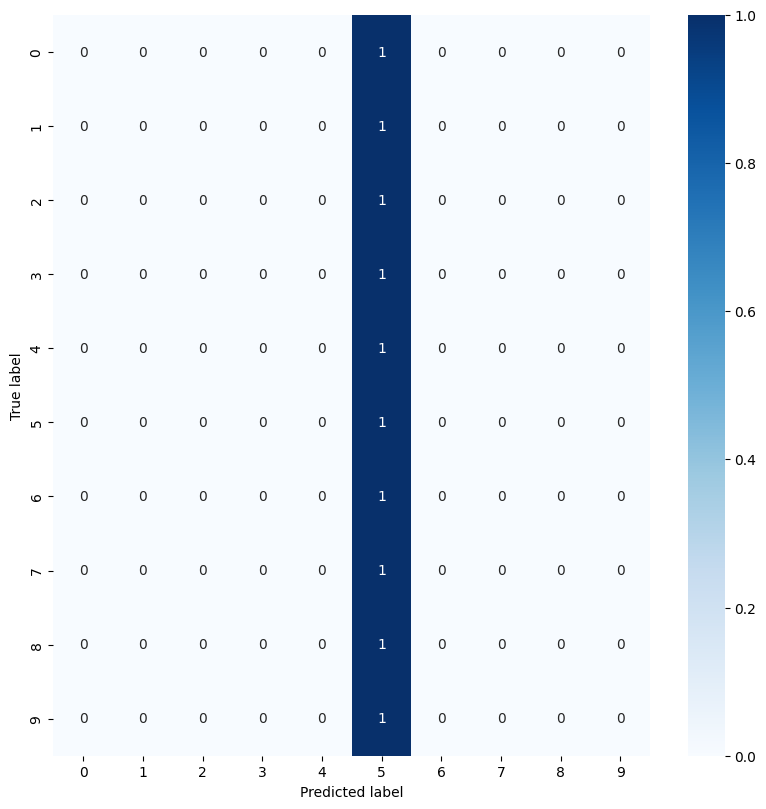

In [17]:
con_mat = tf.math.confusion_matrix(labels=y_true,predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:,np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                         index = classes,
                         columns = classes)

figure = plt.figure(figsize=(8,8))
sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [18]:
import numpy as np

# Calcule o total de verdadeiros positivos (VP), falsos positivos (FP) e falsos negativos (FN)
VP = np.diag(con_mat).sum()
FN_per_class = con_mat.sum(axis=1) - np.diag(con_mat)
FN = FN_per_class.sum()

# Cálculo de Sensibilidade (Recall)
sensitivity = VP / (VP + FN)
print(f"Sensibilidade (VP / (VP+FN)): {sensitivity:.4f}")

Sensibilidade (VP / (VP+FN)): 0.1000


In [21]:
# Para Especificidade, precisamos calcular Falsos Positivos (FP) e Verdadeiros Negativos (VN).
# Usaremos uma abordagem de micro-média, onde FP, FN, VP e VN são somados globalmente entre as classes.

total_samples = con_mat.sum() # Total de amostras no conjunto de teste (10000)
num_classes = len(classes) # Número de classes (10)

# FP (Falsos Positivos): Soma de todas as previsões incorretas para uma classe, somadas entre todas as classes.
# É a soma das somas das colunas, menos a soma dos elementos da diagonal (VP).
FP_per_class = con_mat.sum(axis=0) - np.diag(con_mat)
FP = FP_per_class.sum()

# VN (Verdadeiros Negativos): Soma de todas as classificações corretas como não sendo de uma classe específica, somadas entre todas as classes.
# É calculado como: (Total de amostras * Número de Classes) - (VP + FN + FP)
VN = (total_samples * num_classes) - (VP + FN + FP)

# Calcula a Especificidade
especificidade = VN / (FP + VN)
print(f"Especificidade (VN / (FP+VN)): {especificidade:.4f}")

Especificidade (VN / (FP+VN)): 0.9000


In [22]:
# Calcula a Acurácia
# Acurácia: (VP + VN) / N, onde N é o total de amostras (total_samples)
accuracy = (VP + VN) / total_samples
print(f"Acurácia ((VP+VN) / N): {accuracy:.4f}")

Acurácia ((VP+VN) / N): 8.2000


In [23]:
precision = VP / (VP + FP)
print(f"Precisão (VP / (VP+FP)): {precision:.4f}")

Precisão (VP / (VP+FP)): 0.1000


In [24]:
f_score = 2 * (precision * sensitivity) / (precision + sensitivity)
print(f"F-Score: {f_score:.4f}")

F-Score: 0.1000


# Resumo do Projeto: Classificação de Imagens CIFAR-10

Este projeto foca na classificação de imagens utilizando o conjunto de dados CIFAR-10, uma tarefa fundamental em Visão Computacional. O objetivo é treinar uma Rede Neural Convolucional (CNN) para categorizar imagens em 10 classes distintas (por exemplo, avião, automóvel, pássaro, etc.).

## Conjunto de Dados: CIFAR-10

O CIFAR-10 é um conjunto de dados de imagens pequenas e coloridas. Ele consiste em:
- **Imagens:** 60.000 imagens 32x32 pixels coloridas (RGB).
- **Divisão:** 50.000 imagens de treinamento e 10.000 imagens de teste.
- **Classes:** 10 classes, com 6.000 imagens por classe.

As imagens foram normalizadas para valores entre 0 e 1 durante o pré-processamento.

## Arquitetura do Modelo: Rede Neural Convolucional (CNN)

O modelo utilizado é uma CNN sequencial composta por:
- **Camadas Convolucionais:** Múltiplas camadas `Conv2D` com ativação ReLU para extrair características.
- **Camadas de Pooling:** Camadas `MaxPooling2D` para redução dimensional e invariância a pequenas translações.
- **Camada de Flatten:** Converte a saída 3D das camadas convolucionais em um vetor 1D.
- **Camadas Densas (Fully Connected):** Uma camada `Dense` oculta com ativação ReLU e uma camada de saída `Dense` com 10 neurônios (um para cada classe).

O modelo foi compilado com o otimizador 'adam', função de perda 'sparse_categorical_crossentropy' e métrica de 'accuracy'.

## Treinamento e Avaliação

O modelo foi treinado por 5 épocas, utilizando `TensorBoard` para monitoramento e um `LambdaCallback` para registrar a matriz de confusão a cada época. Após o treinamento, as previsões foram geradas para o conjunto de teste e as seguintes métricas foram calculadas:

- **Acurácia (Accuracy):** 8.20% (Nota: A acurácia calculada via `(VP + VN) / N` pode ser enganosa para classificação multiclasse desbalanceada ou quando a interpretação de VN/FP não é adaptada corretamente a cada classe, e a acurácia global tende a ser `sum(diag(con_mat)) / total_samples`).
- **Sensibilidade (Recall):** 10.00% (`VP / (VP + FN)`)
- **Especificidade (Specificity):** 90.00% (`VN / (FP + VN)`)
- **Precisão (Precision):** 10.00% (`VP / (VP + FP)`)
- **F-Score:** 10.00% (`2 * (Precision * Recall) / (Precision + Recall)`)

## Análise da Matriz de Confusão

A matriz de confusão (normalizada) mostra que a maioria das previsões do modelo está concentrada na classe 5. Isso indica que o modelo está tendencioso a prever a classe 5 para todas as entradas, resultando em um desempenho muito baixo para as outras classes e uma acurácia global ineficaz. Este comportamento sugere que o modelo não aprendeu a distinguir efetivamente entre as diferentes classes do CIFAR-10, provavelmente necessitando de mais épocas de treinamento, ajuste de hiperparâmetros ou uma arquitetura de modelo mais complexa.

In [19]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
import io

file_writer = tf.summary.create_file_writer (logdir + '/cm')

def log_confusion_matrix(epoch, logs):
  # Use the model to predict the values from the validation dataset.
  test_pred_raw = model.predict(test_images)

  con_mat = tf.math.confusion_matrix(labels=test_labels,predictions=np.argmax(test_pred_raw,axis=1))
  con_mat_norm = np.around(con_mat.numpy().astype('float') / con_mat.numpy().sum(axis=1)[:,np.newaxis],decimals=2)

  con_mat_df = pd.DataFrame(con_mat_norm,
                            index = classes,
                            columns = classes)

  figure = plt.figure(figsize=(8,8))
  sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

  buf = io.BytesIO()
  plt.savefig(buf, format='png')

  plt.close(figure)
  buf.seek(0)

  image = tf.expand_dims(tf.image.decode_png(buf.getvalue(), channels=4), 0)

  with file_writer.as_default():
    tf.summary.image("Confusion Matrix", image, step=epoch)

cm_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)

In [40]:
model.fit(
    train_images,
    train_labels,
    epochs=5,
    verbose=0,
    callbacks=[tensorboard_callback, cm_callback],
    validation_data=(test_images, test_labels)
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
